In [8]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPoint
import alphashape
from descartes import PolygonPatch


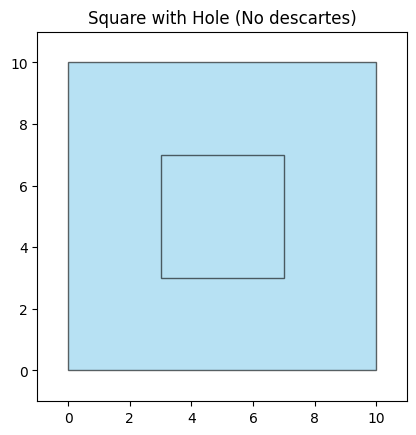

In [12]:
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path

# Outer and hole definitions
outer = [(0, 0), (10, 0), (10, 10), (0, 10), (0, 0)]
hole = [(3, 3), (7, 3), (7, 7), (3, 7), (3, 3)]

# Create polygon with hole
poly = Polygon(shell=outer, holes=[hole])

# Function to convert Shapely polygon to Matplotlib Path
def polygon_to_path(polygon: Polygon):
    vertices = []
    codes = []

    def _ring_to_path(ring):
        ring_coords = list(ring.coords)
        verts = ring_coords
        codes_local = [Path.MOVETO] + [Path.LINETO] * (len(verts) - 2) + [Path.CLOSEPOLY]
        return verts, codes_local

    # Outer boundary
    v, c = _ring_to_path(polygon.exterior)
    vertices.extend(v)
    codes.extend(c)

    # Holes
    for hole in polygon.interiors:
        v, c = _ring_to_path(hole)
        vertices.extend(v)
        codes.extend(c)

    return Path(vertices, codes)

# Convert and plot
path = polygon_to_path(poly)
patch = PathPatch(path, facecolor='skyblue', edgecolor='black', alpha=0.6)

fig, ax = plt.subplots()
ax.add_patch(patch)
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 11)
ax.set_aspect('equal')
plt.title("Square with Hole (No descartes)")
plt.show()


In [13]:
print(poly)

POLYGON ((0 0, 10 0, 10 10, 0 10, 0 0), (3 3, 7 3, 7 7, 3 7, 3 3))


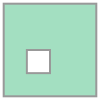

In [16]:
shell = [(0,0), (4,0), (4, 4), (0, 4)]
hole = [(1,1), (2,1), (2,2),(1,2)]
poly = Polygon(shell=shell, holes=[hole])
poly

In [17]:
print(poly)

POLYGON ((0 0, 4 0, 4 4, 0 4, 0 0), (1 1, 2 1, 2 2, 1 2, 1 1))


IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

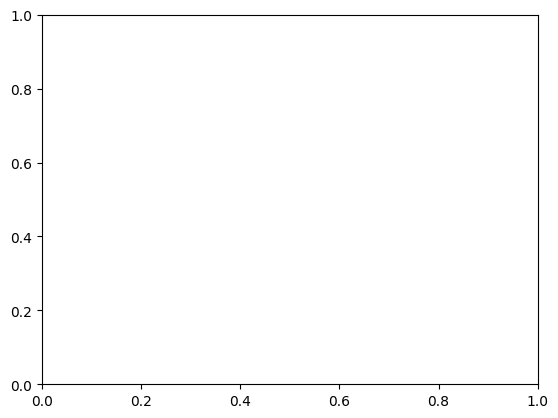

In [18]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from descartes import PolygonPatch

# 1. Define outer shell and hole
shell = [(0, 0), (4, 0), (4, 4), (0, 4)]
hole = [(1, 1), (2, 1), (2, 2), (1, 2)]

# 2. Create shapely polygon with hole
poly = Polygon(shell=shell, holes=[hole])

# 3. Plot with matplotlib
fig, ax = plt.subplots()
patch = PolygonPatch(poly, facecolor='lightgreen', edgecolor='black', alpha=0.8)
ax.add_patch(patch)

# 4. Set limits and show
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_aspect('equal')
plt.show()


In [ ]:
import numpy as np
path = r"C:\DEV\Project2\high_zone_points.npy"
points = np.load(path)
print(points.shape)
print(points.size)  # Print first 5 points


(3, 2)
6


IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

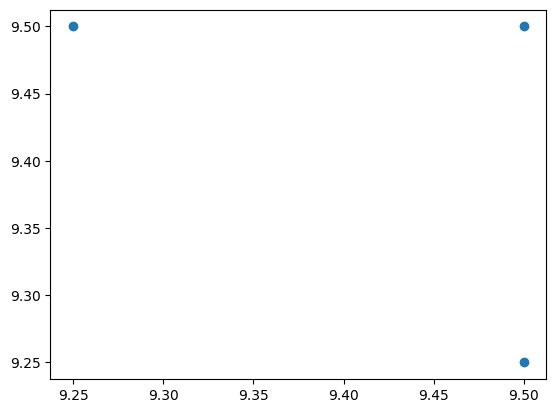

In [ ]:
# Determine the optimized alpha parameter
#alpha = alphashape.optimizealpha(points)
alpha = 0.5
 # Generate the alpha shape
alpha_shape = alphashape.alphashape(points, alpha)

 # Initialize plot
fig, ax = plt.subplots()

 # Plot input points
ax.scatter(*zip(*points))

 # Plot alpha shape
ax.add_patch(PolygonPatch(alpha_shape, alpha=.2))

plt.show()